In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
# load data 
df = pd.read_csv("D:/nassau_profitability_project/data/processed/nassau_featured.csv")
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,country_region,city,state_province,postal_code,...,sales_per_unit,cost_per_unit,cost_ratio,markup_pct,margin_risk_flag,cost_efficiency_flag,profit_category,product_segment,revenue_contribution_pct,profit_contribution_pct
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,...,3.25,1.14,0.350769,185.087719,Healthy,Efficient,Low Profit,Low Performer,0.004584,0.004516
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,3.75,1.30,0.346667,188.461538,Healthy,Efficient,Low Profit,Low Performer,0.005290,0.005244
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,3.49,1.00,0.286533,249.000000,Healthy,Efficient,Medium Profit,Star Product,0.007384,0.007994
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,3.60,1.10,0.305556,227.272727,Healthy,Efficient,Medium Profit,Star Product,0.007617,0.008026
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,3.75,1.30,0.346667,188.461538,Healthy,Efficient,Medium Profit,High Sales Low Margin,0.007935,0.007866


In [5]:
#Create monthly sales table

monthly_ml = df.groupby("year_month", as_index=False).agg({
    "sales": "sum",
    "gross_profit": "sum"
})

In [6]:
# sort correctly 
monthly_ml["year_month"] = pd.to_datetime(monthly_ml["year_month"])
monthly_ml = monthly_ml.sort_values("year_month").reset_index(drop=True)
monthly_ml

,year_month,sales,gross_profit
0,2024-01-01,2093.90,1366.14
1,2024-02-01,1379.87,908.59
2,2024-03-01,4138.90,2671.16
3,2024-04-01,3988.22,2612.81
4,2024-05-01,3951.52,2615.44
5,2024-06-01,3518.76,2330.72
6,2024-07-01,3865.38,2565.26
7,2024-08-01,4477.65,2945.87
8,2024-09-01,7912.10,5206.70
9,2024-10-01,4815.98,3119.46


In [7]:
#3) Create numeric index for ML

#ML models need numeric input.
monthly_ml["month_index"] = range(len(monthly_ml))
monthly_ml

,year_month,sales,gross_profit,month_index
0,2024-01-01,2093.90,1366.14,0
1,2024-02-01,1379.87,908.59,1
2,2024-03-01,4138.90,2671.16,2
3,2024-04-01,3988.22,2612.81,3
4,2024-05-01,3951.52,2615.44,4
5,2024-06-01,3518.76,2330.72,5
6,2024-07-01,3865.38,2565.26,6
7,2024-08-01,4477.65,2945.87,7
8,2024-09-01,7912.10,5206.70,8
9,2024-10-01,4815.98,3119.46,9


In [8]:
# 4) Train Linear Regression model for sales
X = monthly_ml[["month_index"]]
y = monthly_ml["sales"]

sales_model = LinearRegression()
sales_model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
#5) Predict on historical data
monthly_ml["predicted_sales"] = sales_model.predict(X)
monthly_ml.head()q

,year_month,sales,gross_profit,month_index,predicted_sales
0,2024-01-01,2093.90,1366.14,0,2393.387200
1,2024-02-01,1379.87,908.59,1,2698.975378
2,2024-03-01,4138.90,2671.16,2,3004.563557
3,2024-04-01,3988.22,2612.81,3,3310.151735
4,2024-05-01,3951.52,2615.44,4,3615.739913


In [ ]:
#6) Evaluate model
# MAE - average prediction error 
# R2 - how well trained is explained 
mae_sales = mean_absolute_error(y, monthly_ml["predicted_sales"])
r2_sales = r2_score(y, monthly_ml["predicted_sales"])

print("Sales Forecasting MAE:", round(mae_sales, 2))
print("Sales Forecasting R2:", round(r2_sales, 4))

Sales Forecasting MAE: 1692.78
Sales Forecasting R2: 0.5168


In [11]:
#7) Forecast future 6 months
future_months = 6

future_df = pd.DataFrame({
    "month_index": range(len(monthly_ml), len(monthly_ml) + future_months)
})

future_df["predicted_sales"] = sales_model.predict(future_df)
future_df

,month_index,predicted_sales
0,24,9727.503478
1,25,10033.091657
2,26,10338.679835
3,27,10644.268013
4,28,10949.856191
5,29,11255.444370


In [12]:
# create proper future date
last_date = monthly_ml["year_month"].max()

future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=future_months,
    freq="MS"
)

future_df["year_month"] = future_dates
future_df

,month_index,predicted_sales,year_month
0,24,9727.503478,2026-01-01
1,25,10033.091657,2026-02-01
2,26,10338.679835,2026-03-01
3,27,10644.268013,2026-04-01
4,28,10949.856191,2026-05-01
5,29,11255.444370,2026-06-01


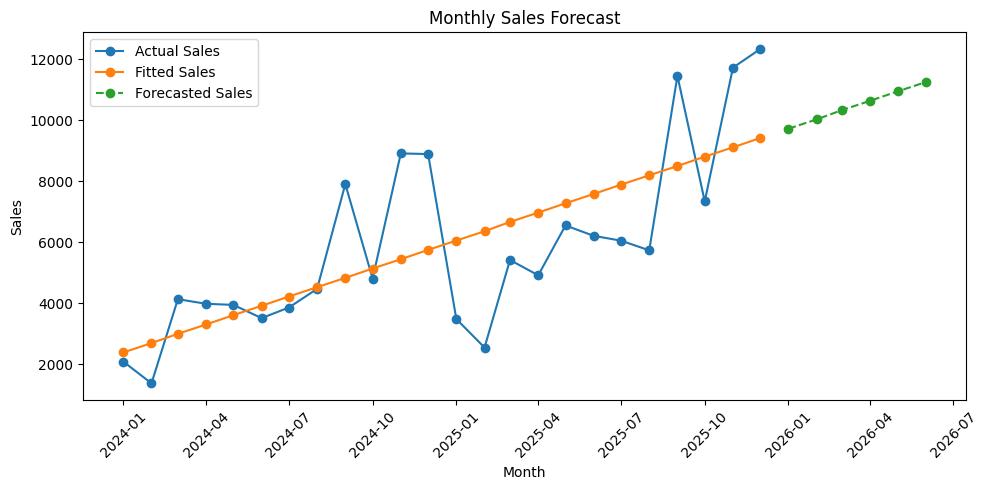

In [13]:
#8) Plot actual vs predicted sales
plt.figure(figsize=(10, 5))
plt.plot(monthly_ml["year_month"], monthly_ml["sales"], marker="o", label="Actual Sales")
plt.plot(monthly_ml["year_month"], monthly_ml["predicted_sales"], marker="o", label="Fitted Sales")
plt.plot(future_df["year_month"], future_df["predicted_sales"], marker="o", linestyle="--", label="Forecasted Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Monthly Sales Forecast")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("D:/nassau_profitability_project/outputs/charts/monthly_sales_forecast.png")
plt.show()

In [14]:
#9) Save forecast table
future_df.to_csv("D:/nassau_profitability_project/outputs/tables/sales_forecast_next_6_months.csv", index=False)
monthly_ml.to_csv("D:/nassau_profitability_project/outputs/tables/monthly_sales_model_output.csv", index=False)

Part B: Profit Forecasting using Linear Regression

In [15]:
#10) Train model for gross profit
X_profit = monthly_ml[["month_index"]]
y_profit = monthly_ml["gross_profit"]

profit_model = LinearRegression()
profit_model.fit(X_profit, y_profit)

monthly_ml["predicted_profit"] = profit_model.predict(X_profit)

In [16]:
# evaluate 
mae_profit = mean_absolute_error(y_profit, monthly_ml["predicted_profit"])
r2_profit = r2_score(y_profit, monthly_ml["predicted_profit"])

print("Profit Forecasting MAE:", round(mae_profit, 2))
print("Profit Forecasting R2:", round(r2_profit, 4))

Profit Forecasting MAE: 1111.73
Profit Forecasting R2: 0.519


In [17]:
# forecast next 6 month 
future_df["predicted_profit"] = profit_model.predict(future_df[["month_index"]])
future_df

,month_index,predicted_sales,year_month,predicted_profit
0,24,9727.503478,2026-01-01,6416.658696
1,25,10033.091657,2026-02-01,6618.515391
2,26,10338.679835,2026-03-01,6820.372087
3,27,10644.268013,2026-04-01,7022.228783
4,28,10949.856191,2026-05-01,7224.085478
5,29,11255.444370,2026-06-01,7425.942174


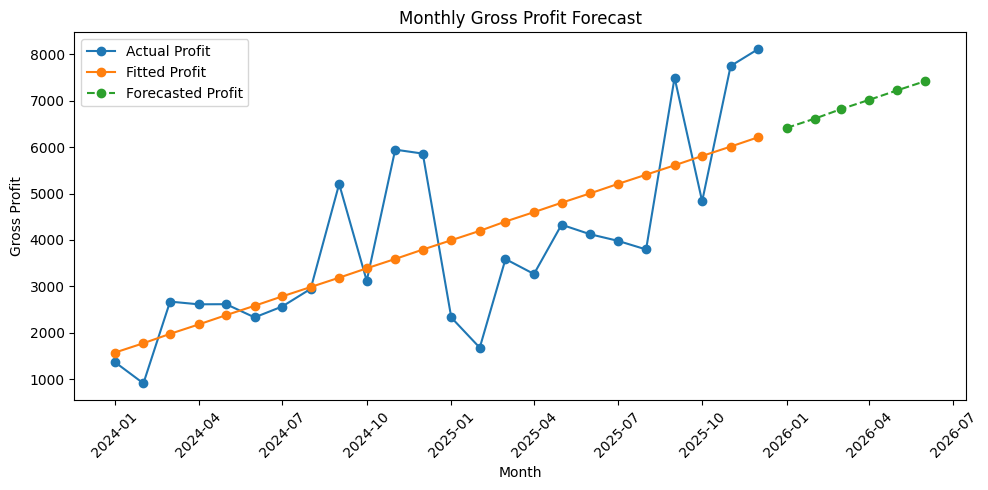

In [ ]:
# plot 
plt.figure(figsize=(10, 5))
plt.plot(monthly_ml["year_month"], monthly_ml["gross_profit"], marker="o", label="Actual Profit")
plt.plot(monthly_ml["year_month"], monthly_ml["predicted_profit"], marker="o", label="Fitted Profit")
plt.plot(future_df["year_month"], future_df["predicted_profit"], marker="o", linestyle="--", label="Forecasted Profit")
plt.xlabel("Month")
plt.ylabel("Gross Profit")
plt.title("Monthly Gross Profit Forecast")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("D:/nassau_profitability_project/outputs/charts/monthly_profit_forecast.png")
plt.show()

In [19]:
future_df.to_csv("D:/nassau_profitability_project/outputs/tables/profit_forecast_next_6_months.csv", index=False)
monthly_ml.to_csv("D:/nassau_profitability_project/outputs/tables/monthly_profit_model_output.csv", index=False)

Part C: Optional K-Means Product Clustering

In [20]:
# 11) load product summary 
product_summary = pd.read_csv("D:/nassau_profitability_project/data/processed/product_summary.csv")
product_summary.head()

,product_id,product_name,division,sales,cost,gross_profit,units,total_orders,gross_margin_pct,profit_per_unit,revenue_contribution_pct,profit_contribution_pct,profit_rank,margin_rank,product_segment
0,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,24890.40,8296.80,16593.60,6914,1527,66.666667,2.40,17.555200,17.758030,5.0,5.0,Star Product
1,CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate,26867.75,9424.38,17443.37,8267,1768,64.923077,2.11,18.949825,18.667431,3.0,7.0,Star Product
2,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,6755.00,16819.95,6755,1529,71.346705,2.49,16.627413,18.000263,4.0,3.0,Star Product
3,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,8517.30,19357.50,7743,1704,69.444444,2.50,19.660098,20.715882,1.0,4.0,Star Product
4,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,9874.80,18610.20,7596,1677,65.333333,2.45,20.090472,19.916141,2.0,6.0,Star Product


In [21]:
# 12) select clustering product
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_features = product_summary[["sales", "gross_profit", "gross_margin_pct"]].copy()

In [22]:
# scale data first
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

In [ ]:
# 13)Apply K-means 
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
product_summary["cluster"] = kmeans.fit_predict(scaled_features)
product_summary.head()

,product_id,product_name,division,sales,cost,gross_profit,units,total_orders,gross_margin_pct,profit_per_unit,revenue_contribution_pct,profit_contribution_pct,profit_rank,margin_rank,product_segment,cluster
0,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,24890.40,8296.80,16593.60,6914,1527,66.666667,2.40,17.555200,17.758030,5.0,5.0,Star Product,0
1,CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate,26867.75,9424.38,17443.37,8267,1768,64.923077,2.11,18.949825,18.667431,3.0,7.0,Star Product,0
2,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,6755.00,16819.95,6755,1529,71.346705,2.49,16.627413,18.000263,4.0,3.0,Star Product,0
3,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,8517.30,19357.50,7743,1704,69.444444,2.50,19.660098,20.715882,1.0,4.0,Star Product,0
4,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,9874.80,18610.20,7596,1677,65.333333,2.45,20.090472,19.916141,2.0,6.0,Star Product,0


In [24]:
#14) Inspect cluster centers
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=["sales", "gross_profit", "gross_margin_pct"]
)

cluster_centers["cluster"] = range(4)
cluster_centers

# save 
cluster_centers.to_csv("D:/nassau_profitability_project/outputs/tables/product_cluster_centers.csv", index=False)

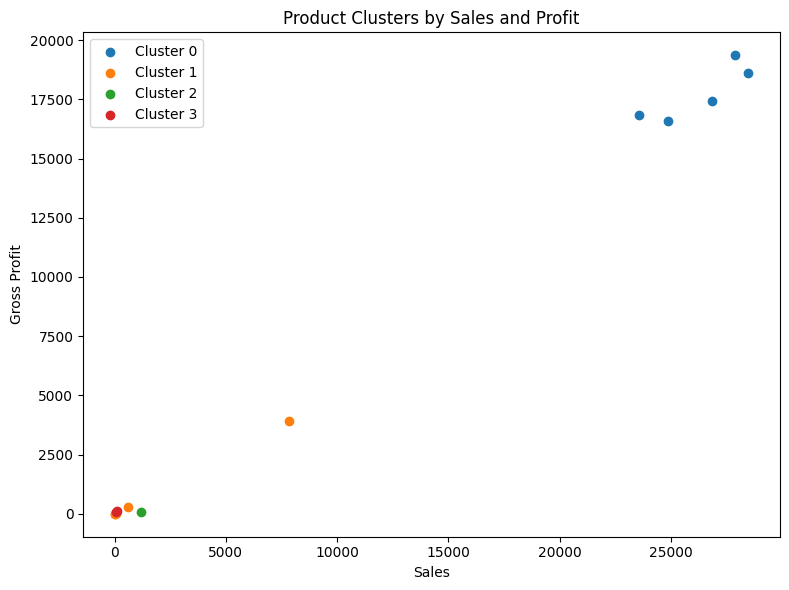

In [25]:
# 15) plot cluster
plt.figure(figsize=(8, 6))
for cluster_id in sorted(product_summary["cluster"].unique()):
    cluster_data = product_summary[product_summary["cluster"] == cluster_id]
    plt.scatter(cluster_data["sales"], cluster_data["gross_profit"], label=f"Cluster {cluster_id}")

plt.xlabel("Sales")
plt.ylabel("Gross Profit")
plt.title("Product Clusters by Sales and Profit")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/charts/product_clusters.png")
plt.show()

In [26]:
# save 
product_summary.to_csv("D:/nassau_profitability_project/outputs/tables/product_summary_with_clusters.csv", index=False)